In [1]:
import matplotlib.pyplot as plt
import numpy as np

# MD simulation to generate training data 

In [ ]:
np.random.seed(3)

# Reduced units for the toy double-well system
dt = 0.005
mass = 1.0                              #for the Li+ this would be about 6.94 amu, but used reduced units here
gamma = 1.0
kBT = 0.4
n_steps = 1e8
burn_in = 5e4                          #steps to ignor before saving trajectory ("equilibration" ål )

# Gaussian double-well parameters
A1, x1, y1, s1 = 3.0, -1.0, 0.0, 0.5
A2, x2, y2, s2 = 3.0, 1.0, 0.0, 0.5
k_confine = 0.2                         #restoring spring constant to prevent ?explosion to infinity of what ål?


def potential(x, y):
    g1 = A1 * np.exp(-((x - x1) ** 2 + (y - y1) ** 2) / (2 * s1 ** 2))
    g2 = A2 * np.exp(-((x - x2) ** 2 + (y - y2) ** 2) / (2 * s2 ** 2))
    return -(g1 + g2) + 0.5 * k_confine * (x ** 2 + y ** 2)


def force_x(x, y):
    g1 = A1 * np.exp(-((x - x1) ** 2 + (y - y1) ** 2) / (2 * s1 ** 2))
    g2 = A2 * np.exp(-((x - x2) ** 2 + (y - y2) ** 2) / (2 * s2 ** 2))
    return -g1 * (x - x1) / s1 ** 2 - g2 * (x - x2) / s2 ** 2 - k_confine * x


def force_y(x, y):
    g1 = A1 * np.exp(-((x - x1) ** 2 + (y - y1) ** 2) / (2 * s1 ** 2))
    g2 = A2 * np.exp(-((x - x2) ** 2 + (y - y2) ** 2) / (2 * s2 ** 2))
    return -g1 * (y - y1) / s1 ** 2 - g2 * (y - y2) / s2 ** 2 - k_confine * y


# Underdamped Langevin dynamics in reduced units
x, y = -1.0, 0.0
vx, vy = 0.0, 0.0
noise_scale = np.sqrt(2 * gamma * kBT * dt) / mass
x_traj, y_traj = [], []
vx_traj, vy_traj = [], []
energy_traj = []

for step in range(n_steps):
    fx = force_x(x, y)
    fy = force_y(x, y)
    vx += (fx / mass - gamma * vx / mass) * dt + noise_scale * np.random.normal()
    vy += (fy / mass - gamma * vy / mass) * dt + noise_scale * np.random.normal()
    x += vx * dt
    y += vy * dt

    if step >= burn_in:
        x_traj.append(x)
        y_traj.append(y)
        vx_traj.append(vx)
        vy_traj.append(vy)
        energy_traj.append(potential(x, y))

positions = np.column_stack((x_traj, y_traj)).astype(np.float32)
velocities = np.column_stack((vx_traj, vy_traj)).astype(np.float32)
energy_traj = np.asarray(energy_traj, dtype=np.float32)

import datetime
date = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")    
np.savez_compressed(
    #f"/Users/clarawimmelmann/Desktop/Energy_specialCourse/init_problem/train_data/double_well_data_{n_steps}steps_{burn_in}burn_{date}.npz",
    f"/Users/clarawimmelmann/Desktop/Energy_specialCourse/init_problem/train_data/double_well_data_{n_steps}steps_{burn_in}burn.npz",
    positions=positions,
    velocities=velocities,
    energy=energy_traj,
)


### calculate analytical diffusion coeffecient with Kramers rule and Einstein coefficient:

In [28]:
# Measure k_obs from simulated trajectory
x_arr = np.asarray(x_traj)
states = (x_arr > 0).astype(int)
n_transitions = np.sum(np.abs(np.diff(states)))
total_time = len(x_arr) * dt
# Mean First Passage Time (MFPT)
mfpt = (2 * total_time) / n_transitions if n_transitions > 0 else np.nan
k_obs = 1.0 / mfpt

# Potential Barrier Params
# Well 1 minimum (x = -1, y = 0) and barrier top (x = 0, y = 0)
V_min = potential(-1.0, 0.0)
V_top = potential(0.0, 0.0)
delta_V = V_top - V_min

# Curvatures (2nd derivatives d²V/dx²)
# Analytical approximation for V''(x) around min and top
dx = 1e-4
d2V_well = (potential(-1.0 + dx, 0.0) - 2*potential(-1.0, 0.0) + potential(-1.0 - dx, 0.0)) / (dx**2)
d2V_top = (potential(0.0 + dx, 0.0) - 2*potential(0.0, 0.0) + potential(0.0 - dx, 0.0)) / (dx**2)

omega_min = np.sqrt(d2V_well / mass)
omega_ts = np.sqrt(np.abs(d2V_top) / mass)

# Kramers Underdamped (standard) Transition Rate Calculation
# Transmission factor for underdamped regime
prefactor = np.sqrt(1 + (gamma / (2 * omega_ts))**2) - (gamma / (2 * omega_ts))
k_kramers = prefactor * (omega_min / (2 * np.pi)) * np.exp(-delta_V / kBT)

print(f"Barrier Height Delta V:       {delta_V:.4f}")
print(f"Observed MD Rate (k_obs):     {k_obs:.6f}")
print(f"Kramers Analytical Rate:      {k_kramers:.6f}")
print(f"Ratio (k_obs / k_kramers):    {k_obs / k_kramers:.3f}")

#ål ask  about this, I think it is not correct to use the observed k_obs to calculate the diffusion coeffecient, but rather the k_kramers analytical rate.

#Einstein theorem for diffusion coefficient D_0: D_0 = kBT / (mass * gamma)
D_0 = kBT / (mass * gamma)
print(f"Analytical Einstein diffusion coefficient:    {D_0:.3f}")
#put in gamma i.e. friction coeffecient from Kramers rate prefactor:
#A=2*np.pi*k_obs/omega_min*np.exp(delta_V/kBT)
A=2*np.pi*k_kramers/omega_min*np.exp(delta_V/kBT)
D_1 = kBT / (mass * omega_ts*(1/A - A))
print(f"Analytical Kramers Einstein diffusion coefficient:    {D_1:.3f}")

Barrier Height Delta V:       2.0890
Observed MD Rate (k_obs):     0.003233
Kramers Analytical Rate:      0.002546
Ratio (k_obs / k_kramers):    1.270
Analytical Einstein diffusion coefficient:    0.400
Analytical Kramers Einstein diffusion coefficient:    0.400


### estimating the equilibrium step from the simulation temperature through the velocities:

/Users/clarawimmelmann/Desktop/Energy_specialCourse/special_energy/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


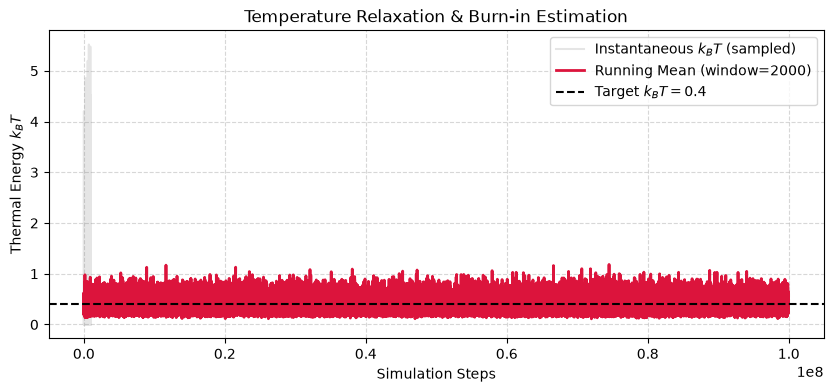

In [ ]:
vx_all = np.array(vx_traj) # full trajectory before burn-in
vy_all = np.array(vy_traj) # full trajectory before burn-in

# Instantaneous kBT (2D kinetic energy)
kBT_inst = 0.5 * mass * (vx_all**2 + vy_all**2)


#plot convergence:
def running_mean(data, window_size=1000):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# Compute moving average over a window
window = 2000 #steps
kBT_smooth = running_mean(kBT_inst, window_size=window)
steps = np.arange(len(kBT_smooth)) + window

plt.figure(figsize=(10, 4))
plt.plot(kBT_inst[::100], alpha=0.2, color='gray', label='Instantaneous $k_B T$ (sampled)')
plt.plot(steps, kBT_smooth, color='crimson', lw=2, label=f'Running Mean (window={window})')
plt.axhline(0.4, color='black', linestyle='--', label='Target $k_B T = 0.4$')

plt.title("Temperature Relaxation & Burn-in Estimation")
plt.xlabel("Simulation Steps")
plt.ylabel("Thermal Energy $k_B T$")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# visualize results:

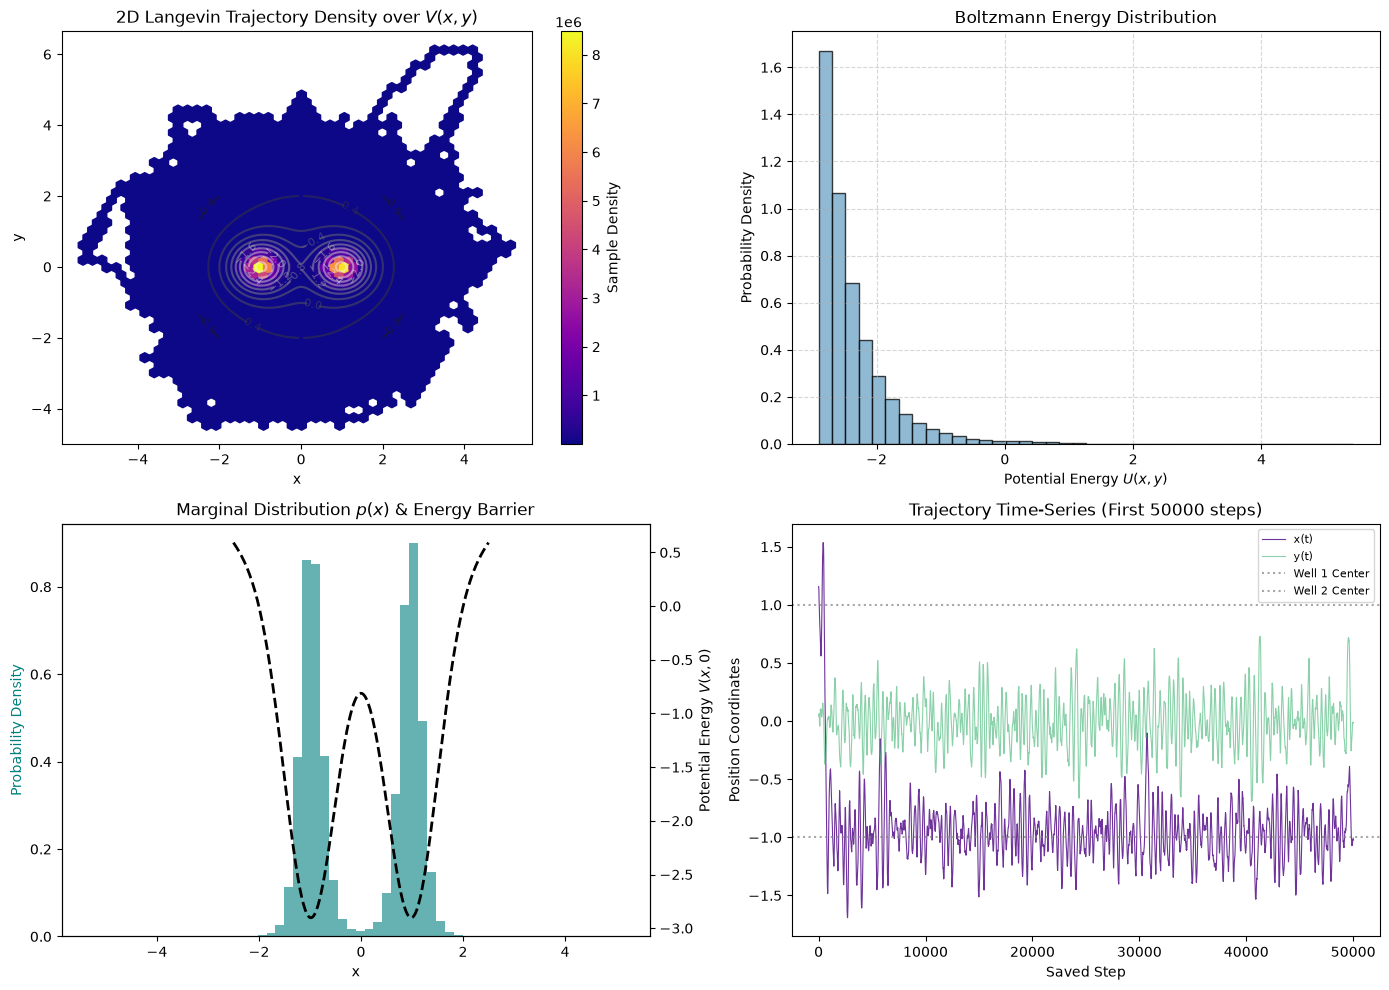

In [22]:
# Ensure trajectory variables are NumPy arrays 
x_traj_arr = np.asarray(x_traj)
y_traj_arr = np.asarray(y_traj)


fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(2, 2)

# subfig 1: 2D Density & Potential Energy Surface
ax1 = fig.add_subplot(gs[0, 0])
x_grid = np.linspace(-2.5, 2.5, 200)
y_grid = np.linspace(-2.0, 2.0, 200)
X, Y = np.meshgrid(x_grid, y_grid)
Z = potential(X, Y)
contour = ax1.contour(X, Y, Z, levels=12, cmap='Greys', alpha=0.5)
ax1.clabel(contour, inline=True, fontsize=8)
hb = ax1.hexbin(x_traj_arr, y_traj_arr, gridsize=45, cmap='plasma', mincnt=1)
fig.colorbar(hb, ax=ax1, label='Sample Density')
ax1.set_title("2D Langevin Trajectory Density over $V(x,y)$")
ax1.set_xlabel("x")
ax1.set_ylabel("y")

# subfig 2: Boltzmann Energy Distribution
ax2 = fig.add_subplot(gs[0, 1])
energies = potential(x_traj_arr, y_traj_arr)
ax2.hist(energies, bins=40, density=True, color='#6ba2c6', edgecolor='black', alpha=0.75)
ax2.set_title("Boltzmann Energy Distribution")
ax2.set_xlabel("Potential Energy $U(x, y)$")
ax2.set_ylabel("Probability Density")
ax2.grid(True, linestyle='--', alpha=0.5)

# subfig 3: 1D Position Marginal vs Potential Profile
ax3 = fig.add_subplot(gs[1, 0])
ax3_twin = ax3.twinx()
ax3.hist(x_traj_arr, bins=60, density=True, color='teal', alpha=0.6, label='Sample Density $p(x)$')
x_line = np.linspace(-2.5, 2.5, 300)
ax3_twin.plot(x_line, potential(x_line, 0.0), color='black', lw=2, linestyle='--', label='$V(x, 0)$')
ax3.set_title("Marginal Distribution $p(x)$ & Energy Barrier")
ax3.set_xlabel("x")
ax3.set_ylabel("Probability Density", color='teal')
ax3_twin.set_ylabel("Potential Energy $V(x, 0)$", color='black')

# subfig 4: Trajectory Walk (Barrier Hopping Time-Series)
ax4 = fig.add_subplot(gs[1, 1])
steps = np.arange(len(x_traj_arr))
#ax4.plot(steps[:5000], x_traj_arr[:5000], label='x(t)', color='indigo', alpha=0.8, lw=0.8)
#ax4.plot(steps[:5000], y_traj_arr[:5000], label='y(t)', color='mediumseagreen', alpha=0.6, lw=0.8)
ax4.plot(steps[:burn_in], x_traj_arr[:burn_in], label='x(t)', color='indigo', alpha=0.8, lw=0.8)
ax4.plot(steps[:burn_in], y_traj_arr[:burn_in], label='y(t)', color='mediumseagreen', alpha=0.6, lw=0.8)
ax4.axhline(-1.0, color='gray', linestyle=':', alpha=0.7, label='Well 1 Center')
ax4.axhline(1.0, color='gray', linestyle=':', alpha=0.7, label='Well 2 Center')
ax4.set_title(f"Trajectory Time-Series (First {burn_in} steps)")
ax4.set_xlabel("Saved Step")
ax4.set_ylabel("Position Coordinates")
ax4.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig(f"/Users/clarawimmelmann/Desktop/Energy_specialCourse/init_problem/MD/viz_underdamped_{n_steps}steps_{burn_in}burn_{date}.png", dpi=300)
plt.show()

# archive 

In [ ]:
### calculate analytical diff coeffecient from observed transition rates

x_arr = np.asarray(x_traj)

# Define state masks (1 when in right well, 0 when in left well)
states = (x_arr > 0).astype(int)

# Detect state changes (0 -> 1 or 1 -> 0)
transitions = np.abs(np.diff(states))
total_transitions = np.sum(transitions)

# Total physical time saved in the trajectory
total_time = len(x_arr) * dt

# Mean First Passage Time (MFPT)
mfpt = (2 * total_time) / total_transitions if total_transitions > 0 else np.nan

# Observed Rate k_obs
k_obs = 1.0 / mfpt

print(f"Total transitions observed: {total_transitions}")
print(f"Mean First Passage Time (MFPT): {mfpt:.2f} time units")
print(f"Observed Rate k_obs: {k_obs:.6f}")

In [ ]:
# Measure k_obs from simulated trajectory
x_arr = np.asarray(x_traj)
states = (x_arr > 0).astype(int)
n_transitions = np.sum(np.abs(np.diff(states)))
total_time = len(x_arr) * dt
# Mean First Passage Time (MFPT)
mfpt = (2 * total_time) / n_transitions if n_transitions > 0 else np.nan
k_obs = 1.0 / mfpt

# Potential Barrier Params
# Well 1 minimum (x = -1, y = 0) and barrier top (x = 0, y = 0)
V_min = potential(-1.0, 0.0)
V_top = potential(0.0, 0.0)
delta_V = V_top - V_min

# Curvatures (2nd derivatives d²V/dx²)
# Analytical approximation for V''(x) around min and top
dx = 1e-4
d2V_well = (potential(-1.0 + dx, 0.0) - 2*potential(-1.0, 0.0) + potential(-1.0 - dx, 0.0)) / (dx**2)
d2V_top = (potential(0.0 + dx, 0.0) - 2*potential(0.0, 0.0) + potential(0.0 - dx, 0.0)) / (dx**2)

omega_min = np.sqrt(d2V_well / mass)
omega_ts = np.sqrt(np.abs(d2V_top) / mass)

# Kramers Underdamped (standard) Transition Rate Calculation
# Transmission factor for underdamped regime
prefactor = np.sqrt(1 + (gamma / (2 * omega_ts))**2) - (gamma / (2 * omega_ts))
k_kramers = prefactor * (omega_min / (2 * np.pi)) * np.exp(-delta_V / kBT)

print(f"Barrier Height Delta V:       {delta_V:.4f}")
print(f"Observed MD Rate (k_obs):     {k_obs:.6f}")
print(f"Kramers Analytical Rate:      {k_kramers:.6f}")
print(f"Ratio (k_obs / k_kramers):    {k_obs / k_kramers:.3f}")


#Einstein theorem for diffusion coefficient D_0: D_0 = kBT / (mass * gamma)
#put in gamma i.e. friction coeffecient from Kramers rate prefactor:
A=2*np.pi*k_obs/omega_min*np.exp(delta_V/kBT)
D_0 = kBT / (mass * omega_ts*(1/A - A))
print(f"Analytical Kramers Einstein diffusion coefficient:    {D_0:.3f}")